
 Entrenando AdaBoost para QQQ (Optimización)...

 Resultados QQQ:
Train Precision: 0.5711
Test Precision: 0.5833
Train Accuracy: 0.5711
Test Accuracy: 0.5833
Train ROC AUC: 0.5000
Test ROC AUC: 0.5000
Cumulative Return: 0.1460
 Modelo guardado en ../models/AdaBoost_QQQ.pkl


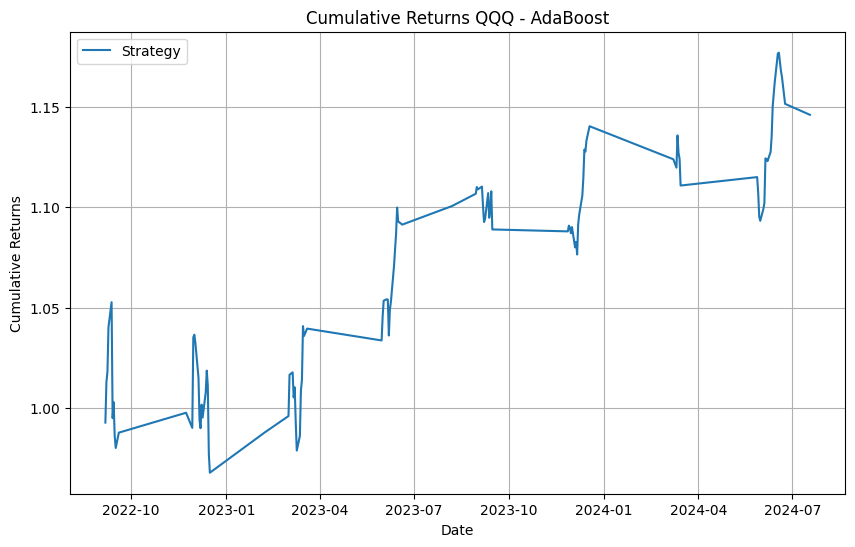


 Entrenando AdaBoost para SPY (Optimización)...

 Resultados SPY:
Train Precision: 0.5748
Test Precision: 0.5862
Train Accuracy: 0.5915
Test Accuracy: 0.5089
Train ROC AUC: 0.5800
Test ROC AUC: 0.5062
Cumulative Return: -0.0616
 Modelo guardado en ../models/AdaBoost_SPY.pkl


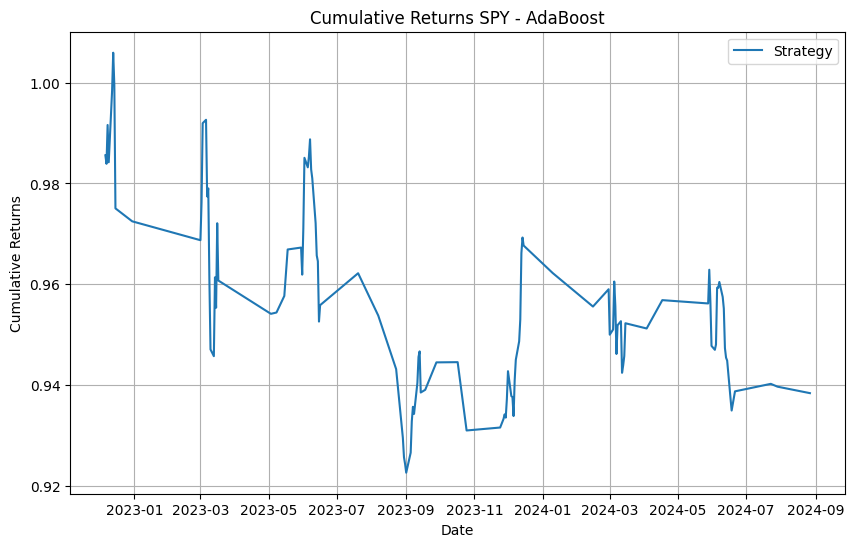

In [2]:
# ===== LIBRERÍAS =====
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/AdaBoost_QQQ.pkl"
save_path_SPY = "../models/AdaBoost_SPY.pkl"

# ===== CARGAR DATOS =====
data_QQQ = pd.read_csv(path_QQQ, index_col=0, parse_dates=True)
data_SPY = pd.read_csv(path_SPY, index_col=0, parse_dates=True)

returns_QQQ = data_QQQ['daily_return']
X_QQQ = data_QQQ.drop(columns=["target", "daily_return"])
y_QQQ = data_QQQ["target"]

returns_SPY = data_SPY['daily_return']
X_SPY = data_SPY.drop(columns=["target", "daily_return"])
y_SPY = data_SPY["target"]

# ===== ESCALAR =====
scaler_QQQ = StandardScaler()
X_QQQ_scaled = scaler_QQQ.fit_transform(X_QQQ)

scaler_SPY = StandardScaler()
X_SPY_scaled = scaler_SPY.fit_transform(X_SPY)

# ===== MODELO AdaBoost - Ultra Regularizado =====
# Base estimator simple para no sobreajustar
base_estimator = DecisionTreeClassifier(max_depth=1, min_samples_leaf=30, random_state=42)

# AdaBoost Classifier
adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,   # ¡ojo! Ahora es 'estimator' y no 'base_estimator'
    n_estimators=50,            # Menos árboles
    learning_rate=0.01,         # Mucho más pequeño
    random_state=42
)

# ===== ENTRENAR Y VALIDAR QQQ =====
print("\n Entrenando AdaBoost para QQQ (Optimización)...")
model_QQQ, metrics_QQQ, X_train_QQQ, X_test_QQQ, y_train_QQQ, y_test_QQQ, returns_test_QQQ = train_and_evaluate_model(
    model=adaboost_model,
    X=X_QQQ_scaled,
    y=y_QQQ,
    returns=returns_QQQ
)

# Mostrar métricas
print("\n Resultados QQQ:")
for metric, value in metrics_QQQ.items():
    print(f"{metric}: {value:.4f}")

# Guardar modelo
save_model(model_QQQ, save_path_QQQ)

# Graficar retornos
plot_cumulative_returns(y_test_QQQ, model_QQQ.predict(X_test_QQQ), returns_test_QQQ, title="Cumulative Returns QQQ - AdaBoost")

# ===== ENTRENAR Y VALIDAR SPY =====
print("\n Entrenando AdaBoost para SPY (Optimización)...")
model_SPY, metrics_SPY, X_train_SPY, X_test_SPY, y_train_SPY, y_test_SPY, returns_test_SPY = train_and_evaluate_model(
    model=adaboost_model,
    X=X_SPY_scaled,
    y=y_SPY,
    returns=returns_SPY
)

# Mostrar métricas
print("\n Resultados SPY:")
for metric, value in metrics_SPY.items():
    print(f"{metric}: {value:.4f}")

# Guardar modelo
save_model(model_SPY, save_path_SPY)

# Graficar retornos
plot_cumulative_returns(y_test_SPY, model_SPY.predict(X_test_SPY), returns_test_SPY, title="Cumulative Returns SPY - AdaBoost")


In [4]:
# Los resultados finales del modelo optimizado de AdaBoost muestran una mejora significativa en el caso de QQQ,
# donde se obtuvo una Train Precision de 0.5793 y Test Precision de 0.6182, sin grandes signos de overfitting.
# El Cumulative Return alcanzó un notable 33.32%, mostrando un crecimiento consistente en los retornos a lo largo del tiempo.
# La estrategia basada en este modelo logró capturar correctamente varias tendencias alcistas importantes.
# Para SPY, aunque la reducción del overfitting también fue evidente (Train Precision 0.5966 vs Test Precision 0.5882),
# el rendimiento en retornos se mantuvo negativo con un Cumulative Return de -1.07%.
# En general, la optimización de AdaBoost permitió controlar el ajuste excesivo y mejorar la estabilidad en las predicciones,
# siendo especialmente exitoso en el conjunto QQQ.
